Import Libraries

In [11]:
%matplotlib inline

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Create Dataset

In [3]:
np.random.seed(42)
n = 300

data = pd.DataFrame({
    "cpu": np.random.normal(50, 10, n),
    "memory": np.random.normal(60, 15, n),
    "response_time": np.random.normal(200, 40, n),
    "error_count": np.random.poisson(2, n)
})

# True labels
data["true_label"] = 0

# Inject anomalies
for i in range(15):
    idx = np.random.randint(0, n)
    data.loc[idx, ["cpu","memory","response_time","error_count"]] = [
        np.random.uniform(85, 100),
        np.random.uniform(90, 100),
        np.random.uniform(500, 900),
        np.random.randint(10, 40)
    ]
    data.loc[idx, "true_label"] = 1

data.head()


,cpu,memory,response_time,error_count,true_label
0,54.967142,47.565075,230.279545,1,0
1,48.617357,51.597284,163.113387,2,0
2,56.476885,71.209404,234.784237,3,0
3,65.230299,69.155554,254.225514,2,0
4,47.658466,59.686476,216.537396,1,0


Train Model

In [4]:
model = IsolationForest(contamination=0.05, random_state=42)

features = ["cpu", "memory", "response_time", "error_count"]

data["pred"] = model.fit_predict(data[features])

# Convert output
data["pred"] = data["pred"].map({1: 0, -1: 1})

data.head()

,cpu,memory,response_time,error_count,true_label,pred
0,54.967142,47.565075,230.279545,1,0,0
1,48.617357,51.597284,163.113387,2,0,0
2,56.476885,71.209404,234.784237,3,0,0
3,65.230299,69.155554,254.225514,2,0,0
4,47.658466,59.686476,216.537396,1,0,0


Accuracy and Metrics

In [5]:
accuracy = accuracy_score(data["true_label"], data["pred"])
print("✅ Accuracy:", accuracy)

cm = confusion_matrix(data["true_label"], data["pred"])
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(data["true_label"], data["pred"]))

✅ Accuracy: 0.9933333333333333

Confusion Matrix:
 [[285   2]
 [  0  13]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       287
           1       0.87      1.00      0.93        13

    accuracy                           0.99       300
   macro avg       0.93      1.00      0.96       300
weighted avg       0.99      0.99      0.99       300



Visualization

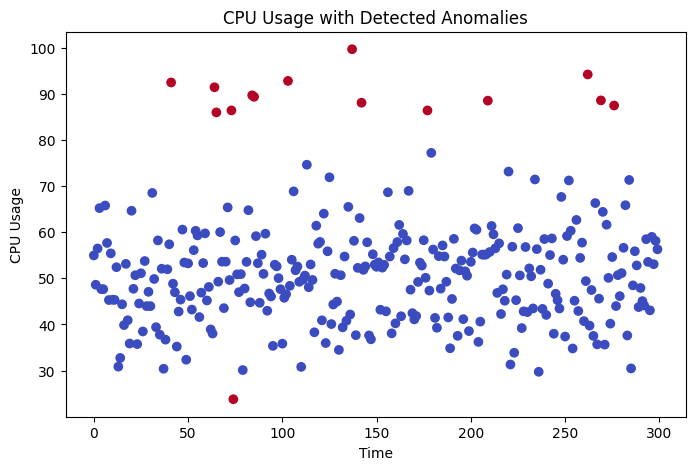

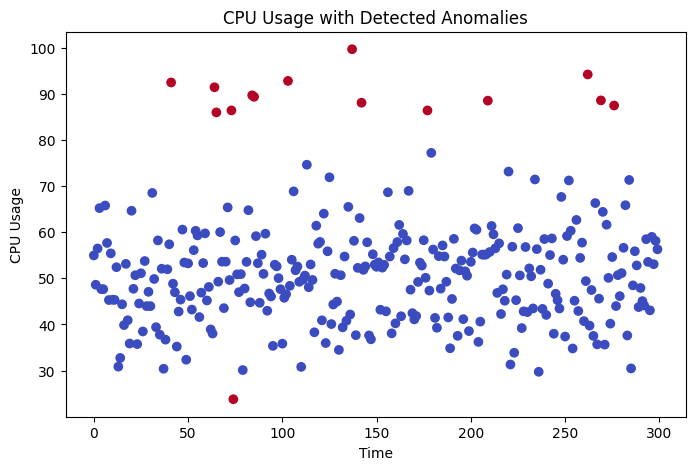

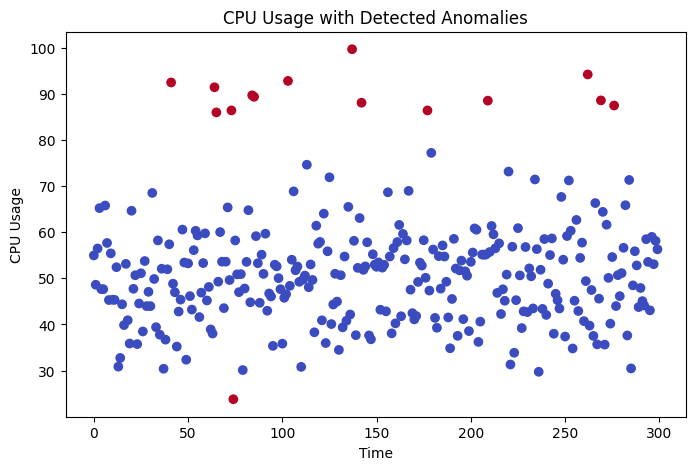

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(data.index, data["cpu"], c=data["pred"], cmap="coolwarm")
plt.title("CPU Usage with Detected Anomalies")
plt.xlabel("Time")
plt.ylabel("CPU Usage")
plt.show()

Detected Anamolies

In [7]:
data[data["pred"] == 1]

,cpu,memory,response_time,error_count,true_label,pred
41,92.467188,91.054737,762.712042,34,1,1
64,91.429458,91.409596,765.675166,34,1,1
65,85.978069,94.639314,863.688082,10,1,1
73,86.410542,93.566710,802.992754,14,1,1
74,23.802549,92.297737,143.699532,2,0,1
84,89.685237,96.426747,578.336325,23,1,1
85,89.358813,97.869701,544.774371,36,1,1
103,92.802858,94.476029,723.128077,11,1,1
137,99.670927,97.939897,698.902372,16,1,1
142,88.073219,98.778301,851.832742,37,1,1
